# การวิเคราะห์เชิงสำรวจข้อมูล PM2.5 ภาคเหนือของประเทศไทย
**โครงการ:** ระบบพยากรณ์ PM2.5 และระบุแหล่งกำเนิดด้วย Spatio-Temporal GNN  
**ช่วงข้อมูล:** 2022–2025 | **จำนวนสถานี:** 18 สถานี | **9 จังหวัดภาคเหนือ**

In [1]:
import warnings
import json
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import folium

warnings.filterwarnings("ignore")
matplotlib.rcParams["figure.dpi"] = 100
sns.set_theme(style="whitegrid", font_scale=0.9)


# ---------------------------------------------------------------------------
# Paths — locate repo root robustly regardless of kernel cwd.
# Walk up from cwd until CLAUDE.md is found. Works whether the kernel
# is started from the repo root or from notebooks/.
# ---------------------------------------------------------------------------
def _find_repo_root(marker: str = "CLAUDE.md") -> Path:
    """Walk up from cwd until the repo marker file is found."""
    candidate = Path.cwd()
    for _ in range(6):
        if (candidate / marker).exists():
            return candidate
        parent = candidate.parent
        if parent == candidate:
            break
        candidate = parent
    # Fallback: notebook is one level below repo root
    return Path.cwd().parent


REPO_ROOT = _find_repo_root()
DATA_DIR = REPO_ROOT / "data" / "processed"
FIGURES_DIR = REPO_ROOT / "notebooks" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------------------------
# Province mapping — hardcoded (no province column in metadata)
# ---------------------------------------------------------------------------
PROVINCE_MAP = {
    # Chiang Mai
    "Yupparaj": "Chiang Mai",
    "Nakhon Ping": "Chiang Mai",
    "Chiang Mai": "Chiang Mai",
    # Chiang Rai
    "Chiang Rai": "Chiang Rai",
    "Chiangrai": "Chiang Rai",
    "Wiang Pa Pao": "Chiang Rai",
    "Mae Suai": "Chiang Rai",
    "Maesai": "Chiang Rai",
    # Lampang
    "Lampang": "Lampang",
    # Lamphun
    "Lamphun": "Lamphun",
    # Mae Hong Son
    "Mae Hong Son": "Mae Hong Son",
    "Mae Hongson": "Mae Hong Son",
    "Debaratana": "Mae Hong Son",
    "Mae Chaem": "Mae Hong Son",
    # Nan
    "Nan": "Nan",
    # Phayao
    "Phayao": "Phayao",
    # Phrae
    "Phrae": "Phrae",
    # Tak
    "Tak": "Tak",
    "Mae Sot": "Tak",
    "Mea Sot": "Tak",
    # Uttaradit (extended station)
    "Uttaradit": "Uttaradit",
    # Phetchabun (extended station)
    "Phetbura": "Phetchabun",
    "Banthasri": "Tak",
}


def get_province(name: str) -> str:
    """Map a station name to its province using substring matching."""
    for key, prov in PROVINCE_MAP.items():
        if key.lower() in name.lower():
            return prov
    return "Unknown"


def short_name(name: str, max_len: int = 22) -> str:
    """Return a shortened station label for plot axes."""
    parts = name.split(",")
    label = parts[-1].strip() if len(parts) > 1 else name.strip()
    if len(label) > max_len:
        label = label[:max_len].rstrip() + "\u2026"
    return label


# ---------------------------------------------------------------------------
# Load data
# ---------------------------------------------------------------------------
df = pd.read_parquet(DATA_DIR / "dataset.parquet")
meta = pd.read_parquet(DATA_DIR / "stations_metadata.parquet")

meta["province"] = meta["name"].apply(get_province)
meta["short_name"] = meta["name"].apply(short_name)

LOW_COV_SENSOR_ID = 1304386
LOW_COV_LOCATION_ID = int(
    meta.loc[meta["sensor_id_pm25"] == LOW_COV_SENSOR_ID, "location_id"].values[0]
)

display(f"Repo root: {REPO_ROOT.resolve()}")
display(f"Dataset shape: {df.shape}")
display(f"Metadata shape: {meta.shape}")
display(df.dtypes)
display(meta[["location_id", "short_name", "province", "lat", "lon"]])

'Repo root: D:\\งาน\\NSC\\pm25-stgnn-thailand'

'Dataset shape: (631152, 10)'

'Metadata shape: (18, 10)'

timestamp                datetime64[us, UTC]
station_id                             int64
pm25_raw                             float32
pm25_scaled                          float32
mask_in_loss                            bool
exclude_from_training                   bool
hour_sin                             float32
hour_cos                             float32
doy_sin                              float32
doy_cos                              float32
dtype: object

,location_id,short_name,province,lat,lon
0,2328,Chiangrai,Chiang Rai,19.909217,99.823467
1,2411,Health Promotion Hospi…,Tak,18.426783,99.757633
2,225567,Maesai Health Office,Chiang Rai,20.427325,99.883842
3,225570,Lampang,Lampang,18.278333,99.506467
4,225579,Yupparaj Wittayalai Sc…,Chiang Mai,18.790933,98.990000
5,225585,Chom Nan Chaloem Phrak…,Nan,16.820833,100.258056
6,225626,Mea Sot,Tak,16.734413,98.566961
7,225630,Phrae,Phrae,18.128367,100.162433
8,225646,Provincial Waterworks…,Unknown,18.282633,99.659817
9,225648,Mae Hongson,Mae Hong Son,19.304550,97.971650


## ชุดข้อมูล

ชุดข้อมูลนี้รวบรวมจากสถานีตรวจวัดคุณภาพอากาศ 18 แห่งในภาคเหนือของประเทศไทย ครอบคลุม 9 จังหวัด ได้แก่ เชียงใหม่ เชียงราย ลำปาง ลำพูน แม่ฮ่องสอน น่าน พะเยา แพร่ และตาก  
ข้อมูลถูกรวบรวมผ่าน OpenAQ v3 API (ผู้ให้ข้อมูล: Air4Thai) ในช่วงปี พ.ศ. 2565–2568 (ค.ศ. 2022–2025) ที่ความละเอียดรายชั่วโมง

**คอลัมน์หลักในชุดข้อมูล:**
- `pm25_raw` — ค่า PM2.5 ดิบ (µg/m³)
- `pm25_scaled` — ค่า PM2.5 ที่ถูก normalize ด้วย RobustScaler
- `mask_in_loss` — True หากช่วงเวลานั้นถูกกำบังออกจาก loss function (ช่องว่างข้อมูล >24 ชั่วโมง)
- `exclude_from_training` — True หากเดือนนั้นถูกยกเว้นจากการฝึกสอน (มีช่องว่าง >7 วัน)
- ค่า encoding เชิงวัฏจักร: `hour_sin`, `hour_cos`, `doy_sin`, `doy_cos`

In [2]:
# ---------------------------------------------------------------------------
# Cell 4 — Coverage computation
# ---------------------------------------------------------------------------

# Pivot to wide form: rows=timestamp, cols=station_id, values=pm25_raw
wide = df.pivot_table(
    index="timestamp", columns="station_id", values="pm25_raw", aggfunc="first"
)

# Overall coverage per station (%)
coverage_by_station = wide.notna().sum() / len(wide) * 100
coverage_by_station.name = "coverage_pct"
coverage_by_station = coverage_by_station.sort_values(ascending=True)

# Maps for display labels
id_to_short = dict(zip(meta["location_id"], meta["short_name"]))
id_to_name = dict(zip(meta["location_id"], meta["name"]))

# Coverage by year: stations (rows) x years (cols)
df["year"] = df["timestamp"].dt.year
cov_year_raw = (
    df.groupby(["station_id", "year"])["pm25_raw"]
    .apply(lambda x: x.notna().sum() / len(x) * 100)
    .reset_index()
)
cov_year_raw.columns = ["station_id", "year", "coverage_pct"]
coverage_by_year = (
    cov_year_raw
    .pivot(index="station_id", columns="year", values="coverage_pct")
    .round(1)
)
coverage_by_year.index = coverage_by_year.index.map(
    lambda sid: id_to_short.get(sid, str(sid))
)
coverage_by_year.index.name = "Station"

display("Coverage by year (% non-null hours):")
display(coverage_by_year)

'Coverage by year (% non-null hours):'

year,2022,2023,2024,2025
Station,,,,
Chiangrai,86.5,76.6,98.9,70.0
Health Promotion Hospi…,94.9,76.7,98.9,70.7
Maesai Health Office,98.0,76.3,98.9,66.9
Lampang,98.8,76.2,98.9,70.2
Yupparaj Wittayalai Sc…,98.8,76.8,98.9,70.8
Chom Nan Chaloem Phrak…,98.5,76.5,97.7,64.3
Mea Sot,98.2,75.5,97.9,70.4
Phrae,86.7,70.8,98.6,70.0
Provincial Waterworks…,96.3,68.1,87.2,70.8


In [3]:
# ---------------------------------------------------------------------------
# Cell 5 — Folium station map
# ---------------------------------------------------------------------------

overall_cov = wide.notna().sum() / len(wide) * 100

station_map = folium.Map(location=[18.5, 99.0], zoom_start=7, tiles="CartoDB positron")

for _, row in meta.iterrows():
    sid = row["location_id"]
    cov_pct = float(overall_cov.get(sid, 0.0))

    if cov_pct >= 80:
        color = "green"
    elif cov_pct >= 50:
        color = "orange"
    else:
        color = "red"

    is_low_cov = int(row["sensor_id_pm25"]) == LOW_COV_SENSOR_ID
    radius = 14 if is_low_cov else 8
    popup_text = (
        f"<b>{row['short_name']}</b><br>"
        f"Province: {row['province']}<br>"
        f"Coverage: {cov_pct:.1f}%<br>"
        f"ID: {sid}"
    )
    if is_low_cov:
        popup_text += "<br><b>Low coverage — flag for exclusion review</b>"

    folium.CircleMarker(
        location=[float(row["lat"]), float(row["lon"])],
        radius=radius,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.75,
        popup=folium.Popup(popup_text, max_width=280),
        tooltip=f"{row['short_name']} ({cov_pct:.0f}%)",
    ).add_to(station_map)

    folium.Marker(
        location=[float(row["lat"]), float(row["lon"])],
        icon=folium.DivIcon(
            html=(
                f'<div style="font-size:9px;color:#333;white-space:nowrap">'
                f"{row['short_name']}</div>"
            ),
            icon_size=(160, 20),
            icon_anchor=(0, -10),
        ),
    ).add_to(station_map)

legend_html = """
<div style="position:fixed;bottom:30px;left:30px;z-index:1000;background:white;
     padding:10px;border:1px solid #ccc;border-radius:5px;font-size:12px">
 <b>Data Coverage</b><br>
 <span style="color:green">&#9679;</span> &ge; 80%<br>
 <span style="color:orange">&#9679;</span> 50&#8211;79%<br>
 <span style="color:red">&#9679;</span> &lt; 50%<br>
 <span style="color:red">&#11044;</span> Low-coverage flag
</div>
"""
station_map.get_root().html.add_child(folium.Element(legend_html))

map_path = FIGURES_DIR / "station_map.html"
station_map.save(str(map_path))
display(f"Map saved to {map_path}")
station_map

'Map saved to D:\\งาน\\NSC\\pm25-stgnn-thailand\\notebooks\\figures\\station_map.html'

## ความครอบคลุมของข้อมูล (Data Coverage)

แผนที่แสดงสถานีตรวจวัด 18 แห่งในภาคเหนือของประเทศไทย โดยสีของวงกลมแสดงระดับความครอบคลุมของข้อมูลรายชั่วโมง:
- **สีเขียว** — ครอบคลุม ≥ 80% (ข้อมูลดี)
- **สีส้ม** — ครอบคลุม 50–79% (ใช้ได้)
- **สีแดง** — ครอบคลุม < 50% (ข้อมูลน้อย)

สถานี **Debaratana Vejjanukul Hospital (Mae Chaem)** ถูกทำเครื่องหมายวงกลมขนาดใหญ่เนื่องจากมีความครอบคลุมต่ำที่สุดในทุกปี (ต่ำกว่า 50% ตลอด พ.ศ. 2565–2568)  
ช่องว่างของข้อมูลที่เกิดขึ้นอย่างเป็นระบบในปี พ.ศ. 2566 ปรากฏในสถานีทั้งหมด และน่าจะเกิดจากการหยุดทำงานของเซ็นเซอร์ Air4Thai ในวงกว้าง

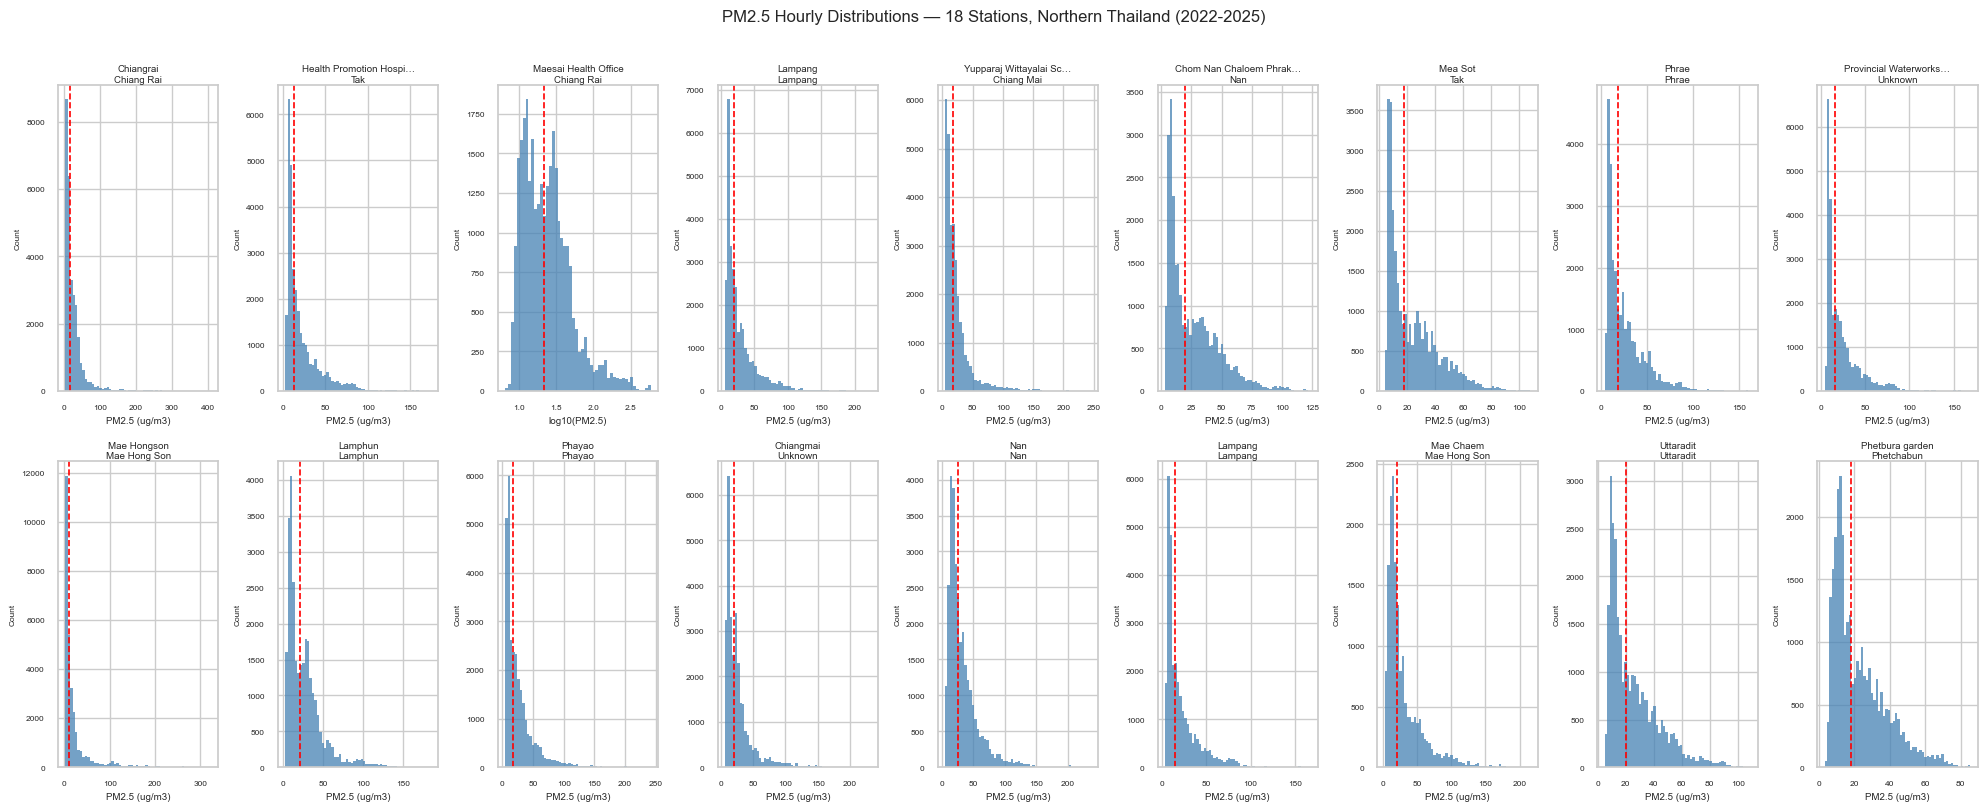

'Saved to D:\\งาน\\NSC\\pm25-stgnn-thailand\\notebooks\\figures\\pm25_distributions.png'

In [4]:
# ---------------------------------------------------------------------------
# Cell 7 — PM2.5 distributions (2 rows x 9 cols)
# ---------------------------------------------------------------------------

station_order = meta["location_id"].tolist()
n_stations = len(station_order)
ncols = 9
nrows = 2

fig, axes = plt.subplots(nrows, ncols, figsize=(20, 8))
axes_flat = axes.flatten()

for ax_idx, sid in enumerate(station_order):
    ax = axes_flat[ax_idx]
    station_meta = meta[meta["location_id"] == sid].iloc[0]
    values = df[df["station_id"] == sid]["pm25_raw"].dropna().values

    if len(values) == 0:
        ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
    else:
        use_log = float(values.max()) > 500
        if use_log:
            log_vals = np.log10(values[values > 0])
            ax.hist(log_vals, bins=50, color="steelblue", alpha=0.75, edgecolor="none")
            ax.set_xlabel("log10(PM2.5)", fontsize=7)
            median_val = float(np.median(values))
            if median_val > 0:
                ax.axvline(np.log10(median_val), color="red", lw=1.2, linestyle="--")
        else:
            ax.hist(values, bins=60, color="steelblue", alpha=0.75, edgecolor="none")
            ax.set_xlabel("PM2.5 (ug/m3)", fontsize=7)
            median_val = float(np.median(values))
            ax.axvline(median_val, color="red", lw=1.2, linestyle="--")

    ax.set_title(
        f"{station_meta['short_name']}\n{station_meta['province']}",
        fontsize=7,
        pad=2,
    )
    ax.tick_params(labelsize=6)
    ax.set_ylabel("Count", fontsize=6)

for ax_idx in range(n_stations, len(axes_flat)):
    axes_flat[ax_idx].set_visible(False)

fig.suptitle(
    "PM2.5 Hourly Distributions — 18 Stations, Northern Thailand (2022-2025)",
    fontsize=12,
    y=1.01,
)
plt.tight_layout()
out_path = FIGURES_DIR / "pm25_distributions.png"
fig.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
display(f"Saved to {out_path}")

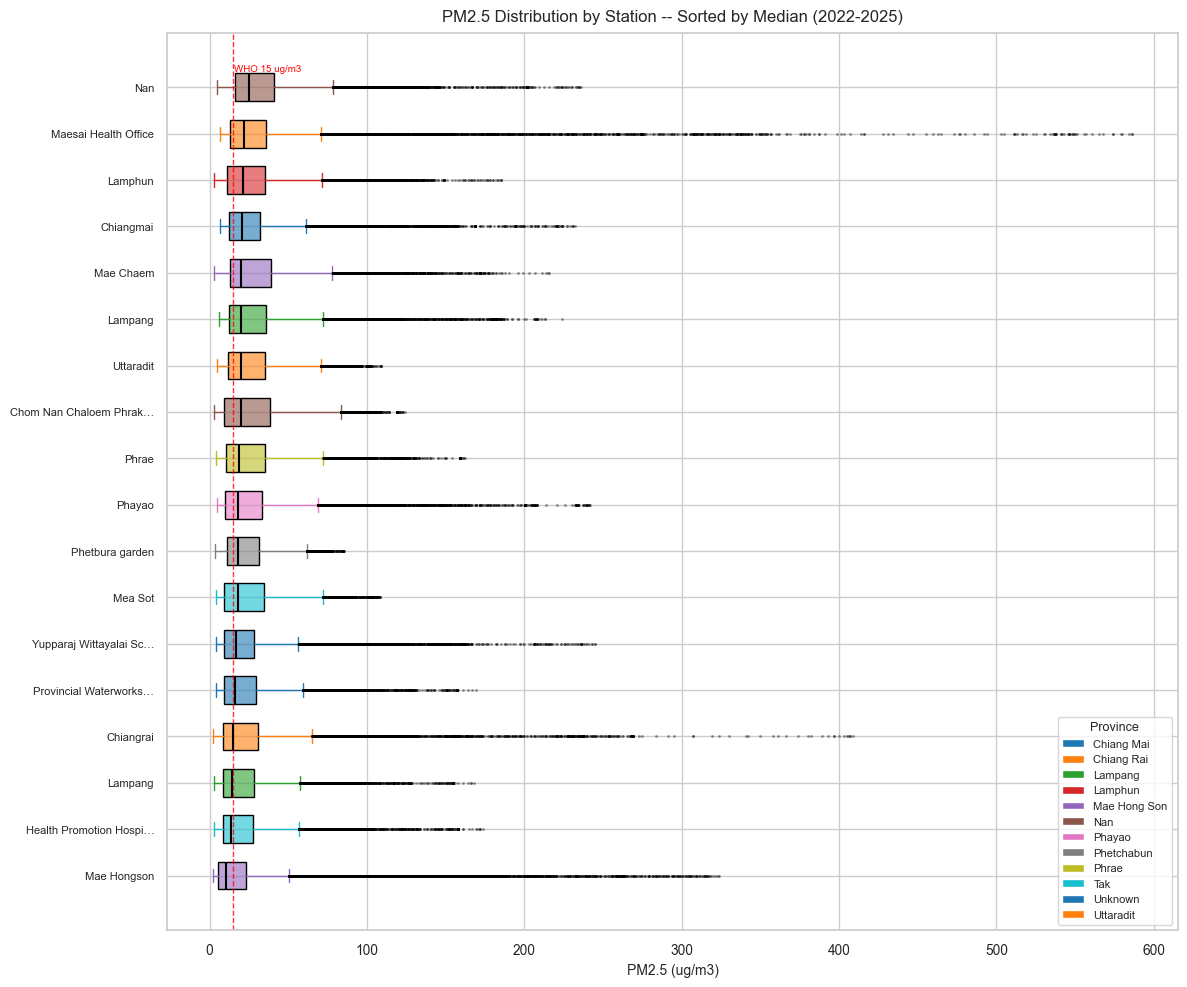

'Saved to D:\\งาน\\NSC\\pm25-stgnn-thailand\\notebooks\\figures\\pm25_boxplots.png'

In [5]:
# ---------------------------------------------------------------------------
# Cell 8 — Horizontal boxplots per station, sorted by median, colored by province
# ---------------------------------------------------------------------------
from matplotlib.patches import Patch

station_medians = (
    df.groupby("station_id")["pm25_raw"]
    .median()
    .reset_index()
    .rename(columns={"pm25_raw": "median_pm25"})
)
station_medians = station_medians.merge(
    meta[["location_id", "short_name", "province"]],
    left_on="station_id",
    right_on="location_id",
    how="left",
).sort_values("median_pm25", ascending=True)

provinces = sorted(meta["province"].unique())
palette = sns.color_palette("tab10", n_colors=len(provinces))
province_color = dict(zip(provinces, palette))

fig, ax = plt.subplots(figsize=(12, 10))

for i, (_, row) in enumerate(station_medians.iterrows()):
    sid = row["station_id"]
    values = df[df["station_id"] == sid]["pm25_raw"].dropna().values
    if len(values) == 0:
        continue
    color = province_color.get(row["province"], "gray")
    # Convert color tuple to list for unpacking
    color_tuple = tuple(color) if not isinstance(color, tuple) else color
    ax.boxplot(
        values,
        positions=[i],
        vert=False,
        widths=0.6,
        patch_artist=True,
        manage_ticks=False,
        flierprops=dict(marker=".", markersize=2, alpha=0.4, color=color_tuple),
        medianprops=dict(color="black", linewidth=1.5),
        boxprops=dict(facecolor=(*color_tuple, 0.6)),
        whiskerprops=dict(color=color_tuple),
        capprops=dict(color=color_tuple),
    )

ax.set_yticks(range(len(station_medians)))
ax.set_yticklabels(station_medians["short_name"].tolist(), fontsize=8)
ax.set_xlabel("PM2.5 (ug/m3)", fontsize=10)
ax.set_title(
    "PM2.5 Distribution by Station -- Sorted by Median (2022-2025)",
    fontsize=12,
    pad=8,
)

legend_patches = [Patch(facecolor=province_color[p], label=p) for p in provinces]
ax.legend(
    handles=legend_patches,
    loc="lower right",
    fontsize=8,
    title="Province",
    title_fontsize=9,
)

ax.axvline(15, color="red", linestyle="--", linewidth=1.0, alpha=0.8)
ax.text(15.5, len(station_medians) - 0.5, "WHO 15 ug/m3", color="red", fontsize=7, va="top")

plt.tight_layout()
out_path = FIGURES_DIR / "pm25_boxplots.png"
fig.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
display(f"Saved to {out_path}")

## สรุปการกระจายตัว

ฮิสโตแกรมและ Boxplot แสดงให้เห็นว่าค่า PM2.5 มีการกระจายตัวแบบ right-skewed อย่างชัดเจน ซึ่งเป็นลักษณะทั่วไปของข้อมูลคุณภาพอากาศ  
ค่ามัธยฐาน (เส้นแดงในฮิสโตแกรม) อยู่ในช่วง 20–50 µg/m³ สำหรับส่วนใหญ่ของสถานี แต่สถานีในจังหวัดเชียงใหม่และแม่ฮ่องสอนมีค่าสูงสุดในช่วงหมอกควัน (Burning Season ระหว่างเดือนกุมภาพันธ์–เมษายน)

ค่า PM2.5 ที่สูงกว่า 500 µg/m³ ปรากฏในบางสถานี ซึ่งเกินกว่าเกณฑ์ WHO 24 ชั่วโมง (15 µg/m³) อย่างมาก  
การ normalize ด้วย **RobustScaler** (Median + IQR) จึงเหมาะสมกว่า Z-score สำหรับชุดข้อมูลนี้

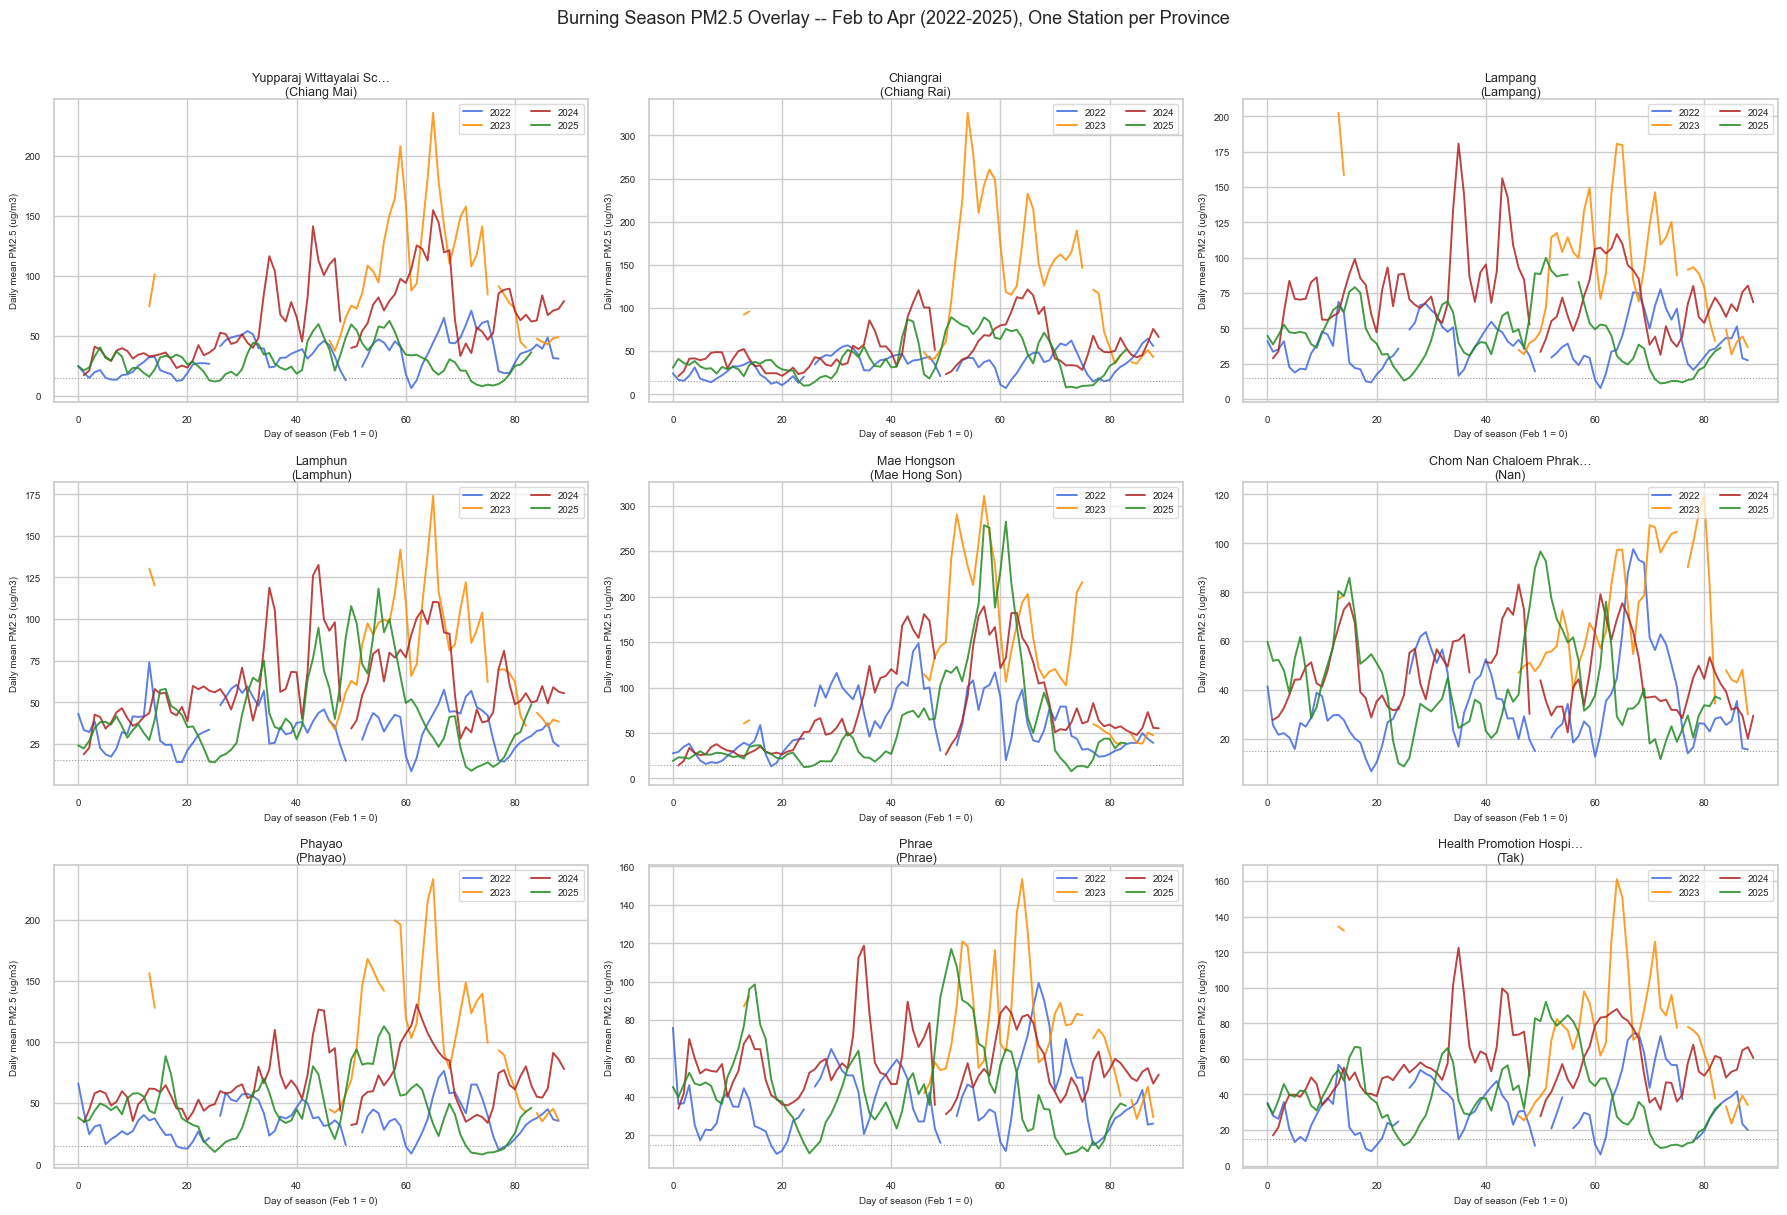

'Saved to D:\\งาน\\NSC\\pm25-stgnn-thailand\\notebooks\\figures\\burning_seasons.png'

In [6]:
# ---------------------------------------------------------------------------
# Cell 10 — Burning season overlay (4 seasons per province)
# ---------------------------------------------------------------------------

prov_representative = (
    meta.groupby("province")["location_id"].first().reset_index()
)
NINE_PROVINCES = [
    "Chiang Mai",
    "Chiang Rai",
    "Lampang",
    "Lamphun",
    "Mae Hong Son",
    "Nan",
    "Phayao",
    "Phrae",
    "Tak",
]
prov_rep_9 = prov_representative[
    prov_representative["province"].isin(NINE_PROVINCES)
].reset_index(drop=True)

year_colors = {
    2022: "royalblue",
    2023: "darkorange",
    2024: "firebrick",
    2025: "forestgreen",
}

fig, axes = plt.subplots(3, 3, figsize=(18, 12), sharey=False)
axes_flat = axes.flatten()

for ax_idx in range(len(axes_flat)):
    if ax_idx >= len(prov_rep_9):
        axes_flat[ax_idx].set_visible(False)
        continue

    prow = prov_rep_9.iloc[ax_idx]
    ax = axes_flat[ax_idx]
    prov = prow["province"]
    sid = prow["location_id"]
    sname = meta.loc[meta["location_id"] == sid, "short_name"].values[0]

    station_df = (
        df[df["station_id"] == sid]
        .copy()
        .set_index("timestamp")
        .sort_index()
    )

    plotted = False
    for year, color in year_colors.items():
        start = pd.Timestamp(f"{year}-02-01", tz="UTC")
        end = pd.Timestamp(f"{year}-04-30 23:00", tz="UTC")
        season_data = station_df.loc[start:end, "pm25_raw"].dropna()
        if season_data.empty:
            continue
        daily = season_data.resample("D").mean()
        x_days = (daily.index - start).days
        ax.plot(
            x_days,
            daily.values,
            color=color,
            linewidth=1.4,
            alpha=0.85,
            label=str(year),
        )
        plotted = True

    ax.axhline(15, color="gray", linewidth=0.8, linestyle=":", alpha=0.8)
    ax.set_title(f"{sname}\n({prov})", fontsize=9, pad=3)
    ax.set_xlabel("Day of season (Feb 1 = 0)", fontsize=7)
    ax.set_ylabel("Daily mean PM2.5 (ug/m3)", fontsize=7)
    ax.tick_params(labelsize=7)
    if plotted:
        ax.legend(fontsize=7, loc="upper right", ncol=2, framealpha=0.7)

fig.suptitle(
    "Burning Season PM2.5 Overlay -- Feb to Apr (2022-2025), One Station per Province",
    fontsize=13,
    y=1.01,
)
plt.tight_layout()
out_path = FIGURES_DIR / "burning_seasons.png"
fig.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
display(f"Saved to {out_path}")

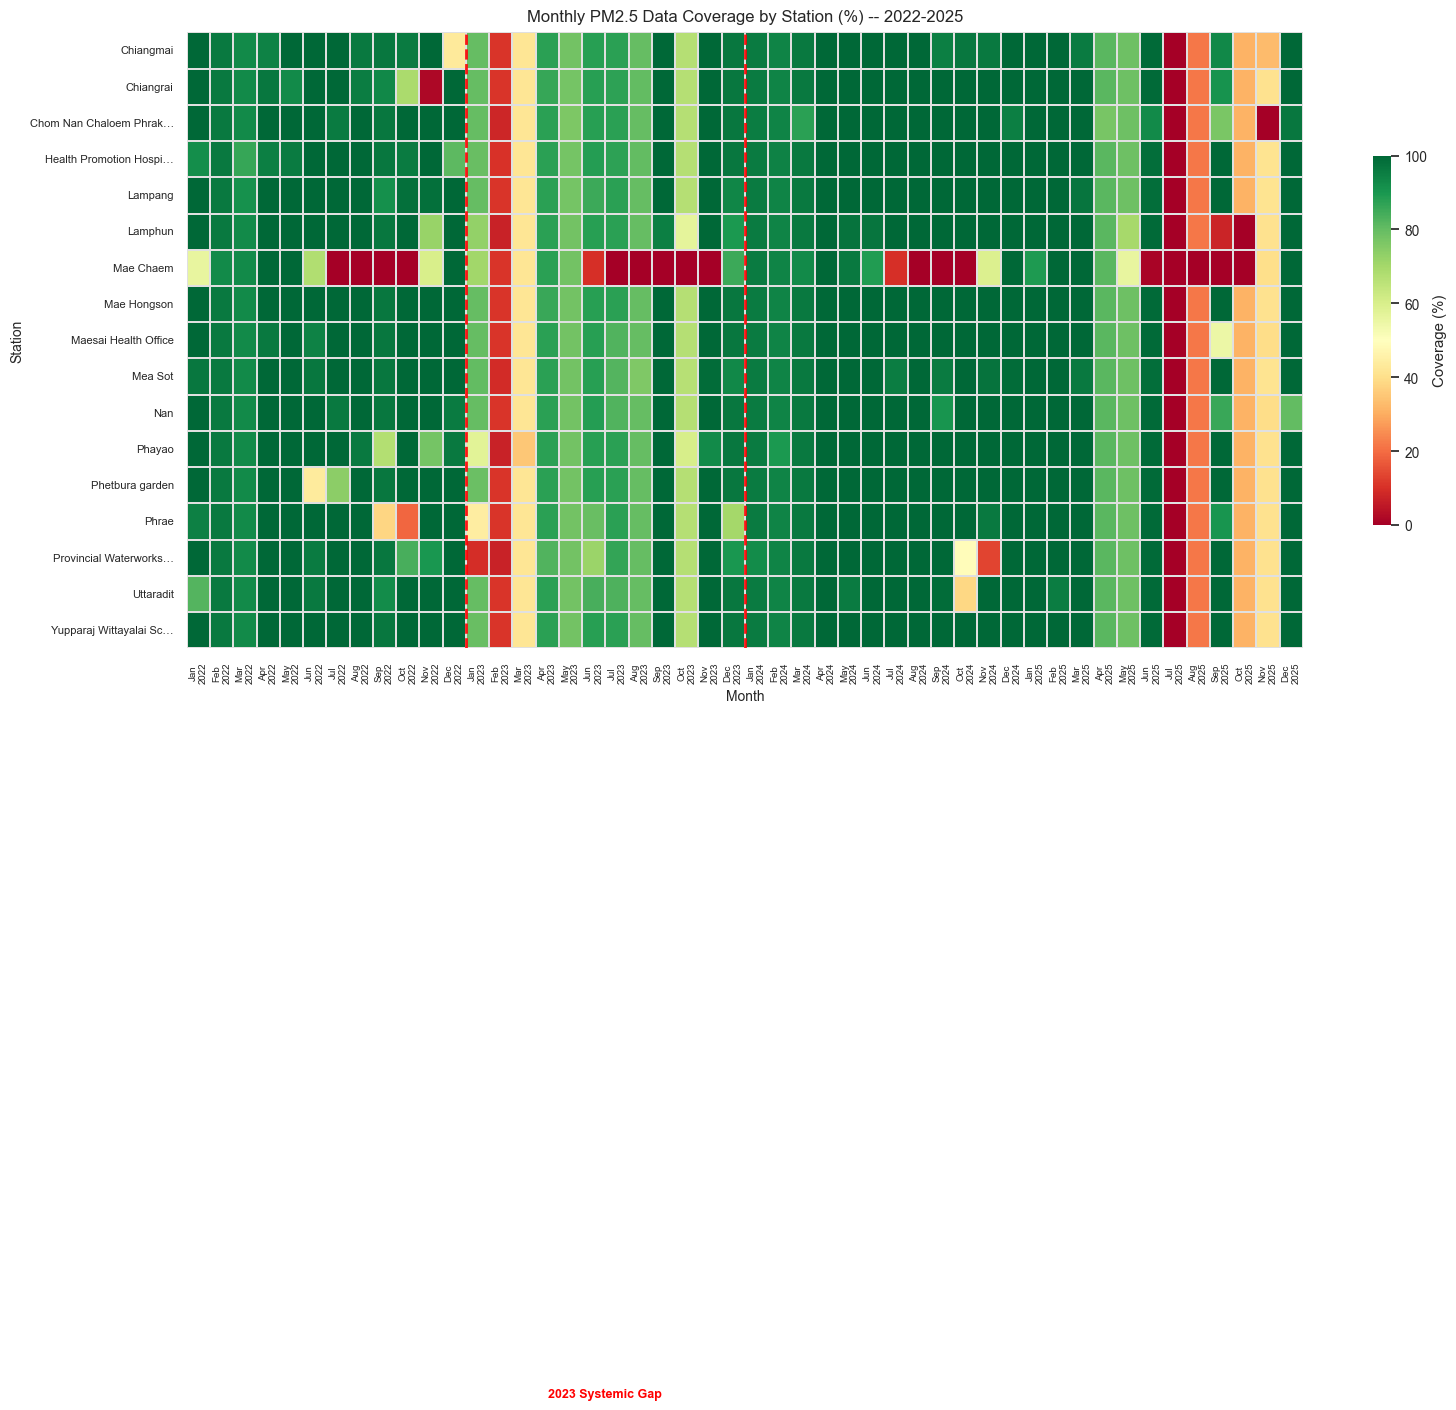

'Saved to D:\\งาน\\NSC\\pm25-stgnn-thailand\\notebooks\\figures\\missing_data_heatmap.png'

In [7]:
# ---------------------------------------------------------------------------
# Cell 11 — Missing-data heatmap (stations x month)
# CRITICAL for proposal: must show 2023 systemic gap clearly
# ---------------------------------------------------------------------------

df["year_month"] = df["timestamp"].dt.to_period("M")

month_total_hours = (
    df.groupby(["station_id", "year_month"])
    .size()
    .rename("total_rows")
)
month_valid_hours = (
    df.groupby(["station_id", "year_month"])["pm25_raw"]
    .apply(lambda x: x.notna().sum())
    .rename("valid_rows")
)

monthly_cov = pd.concat([month_total_hours, month_valid_hours], axis=1).reset_index()
monthly_cov["coverage_pct"] = (
    monthly_cov["valid_rows"] / monthly_cov["total_rows"] * 100
).round(1)
monthly_cov["short_name"] = monthly_cov["station_id"].map(id_to_short)

heatmap_df = monthly_cov.pivot_table(
    index="short_name", columns="year_month", values="coverage_pct"
).sort_index()

all_months = pd.period_range(start="2022-01", end="2025-12", freq="M")
heatmap_df = heatmap_df.reindex(columns=all_months, fill_value=np.nan)

col_labels = [f"{p.strftime('%b')}\n{p.year}" for p in all_months]

fig, ax = plt.subplots(figsize=(18, 8))
sns.heatmap(
    heatmap_df,
    ax=ax,
    cmap="RdYlGn",
    vmin=0,
    vmax=100,
    annot=False,
    linewidths=0.2,
    linecolor="#e0e0e0",
    xticklabels=col_labels,
    yticklabels=True,
    cbar_kws={"label": "Coverage (%)", "shrink": 0.6},
)

ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=7)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=8)
ax.set_xlabel("Month", fontsize=10)
ax.set_ylabel("Station", fontsize=10)
ax.set_title(
    "Monthly PM2.5 Data Coverage by Station (%) -- 2022-2025",
    fontsize=12,
    pad=8,
)

all_months_list = list(all_months)
jan_2023_idx = all_months_list.index(pd.Period("2023-01", "M"))
dec_2023_idx = all_months_list.index(pd.Period("2023-12", "M")) + 1

ax.axvline(x=jan_2023_idx, color="red", linewidth=2.0, linestyle="--", alpha=0.9)
ax.axvline(x=dec_2023_idx, color="red", linewidth=2.0, linestyle="--", alpha=0.9)

mid_2023 = (jan_2023_idx + dec_2023_idx) / 2
ax.text(
    mid_2023,
    -1.2,
    "2023 Systemic Gap",
    ha="center",
    va="top",
    fontsize=9,
    color="red",
    fontweight="bold",
    transform=ax.get_xaxis_transform(),
)

plt.tight_layout()
out_path = FIGURES_DIR / "missing_data_heatmap.png"
fig.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
display(f"Saved to {out_path}")

In [8]:
# ---------------------------------------------------------------------------
# Cell 12 — Province summary table
# ---------------------------------------------------------------------------

overall_cov_df = (
    df.groupby("station_id")["pm25_raw"]
    .apply(lambda x: x.notna().sum() / len(x) * 100)
    .reset_index()
    .rename(columns={"pm25_raw": "coverage_pct"})
)
overall_cov_df = overall_cov_df.merge(
    meta[["location_id", "short_name", "name", "province", "sensor_id_pm25"]],
    left_on="station_id",
    right_on="location_id",
    how="left",
)


def _worst_station_name(group_indices: pd.Series) -> str:
    """Return short name of the lowest-coverage station in the group."""
    sub = overall_cov_df.loc[group_indices.index]
    return sub.loc[sub["coverage_pct"].idxmin(), "short_name"]


province_summary = (
    overall_cov_df.groupby("province")
    .agg(
        n_stations=("station_id", "count"),
        mean_coverage_pct=("coverage_pct", "mean"),
        min_coverage_pct=("coverage_pct", "min"),
        worst_station=("coverage_pct", _worst_station_name),
    )
    .reset_index()
    .sort_values("mean_coverage_pct", ascending=True)
)
province_summary["mean_coverage_pct"] = province_summary["mean_coverage_pct"].round(1)
province_summary["min_coverage_pct"] = province_summary["min_coverage_pct"].round(1)


def _highlight_min_row(row: pd.Series) -> list:
    """Highlight the row with lowest mean coverage."""
    if row["mean_coverage_pct"] == province_summary["mean_coverage_pct"].min():
        return ["background-color: #ffcccc"] * len(row)
    return [""] * len(row)


styled = (
    province_summary.style
    .apply(_highlight_min_row, axis=1)
    .format({"mean_coverage_pct": "{:.1f}%", "min_coverage_pct": "{:.1f}%"})
    .set_caption("Province-Level Data Coverage Summary -- 2022-2025")
)
display(styled)

low_cov_row = overall_cov_df[
    overall_cov_df["sensor_id_pm25"] == LOW_COV_SENSOR_ID
].iloc[0]
display(
    f"NOTE: Station '{low_cov_row['name']}' "
    f"(sensor_id={LOW_COV_SENSOR_ID}, location_id={LOW_COV_LOCATION_ID}) "
    f"has overall coverage of {low_cov_row['coverage_pct']:.1f}% -- "
    f"the lowest of all 18 stations. "
    f"Recommend reviewing exclusion threshold before model training (Session 3)."
)

,province,n_stations,mean_coverage_pct,min_coverage_pct,worst_station
4,Mae Hong Son,2,67.6%,49.0%,Mae Chaem
8,Phrae,1,81.5%,81.5%,Phrae
3,Lamphun,1,82.2%,82.2%,Lamphun
10,Unknown,2,82.4%,80.6%,Provincial Waterworks…
6,Phayao,1,84.0%,84.0%,Phayao
1,Chiang Rai,2,84.0%,83.0%,Chiangrai
11,Uttaradit,1,84.1%,84.1%,Uttaradit
7,Phetchabun,1,84.6%,84.6%,Phetbura garden
5,Nan,2,84.7%,84.3%,Chom Nan Chaloem Phrak…
9,Tak,2,85.4%,85.3%,Health Promotion Hospi…


"NOTE: Station 'Debaratana Vejjanukul Hospital, Mae Chaem' (sensor_id=1304386, location_id=225693) has overall coverage of 49.0% -- the lowest of all 18 stations. Recommend reviewing exclusion threshold before model training (Session 3)."

## สรุปและข้อสังเกต

### ข้อสังเกตสำคัญจากการวิเคราะห์

**1. ช่องว่างของข้อมูลอย่างเป็นระบบในปี พ.ศ. 2566 (2023)**  
สถานีทั้ง 18 แห่งแสดงความครอบคลุมข้อมูลเพียง 38–43% ในปี พ.ศ. 2566 เมื่อเทียบกับ 80–92% ในปีอื่น ๆ  
สาเหตุหลักน่าจะมาจากการหยุดทำงานของเซ็นเซอร์ Air4Thai ในวงกว้าง ซึ่งส่งผลให้ช่วงเวลาที่มีช่องว่างมากกว่า 7 วันถูกยกเว้นออกจากการฝึกสอน (ประมาณ 25.2% ของแถวข้อมูลทั้งหมด)

**2. สถานีที่มีความครอบคลุมต่ำที่สุด: Debaratana Vejjanukul Hospital (Mae Chaem)**  
สถานีนี้มีความครอบคลุมต่ำกว่า 50% ตลอดทุกปีของการศึกษา โดยต่ำที่สุดในปี พ.ศ. 2566 (ประมาณ 20.9%)  
แนะนำให้ทบทวนการตัดสินใจยกเว้นสถานีนี้ออกก่อนเริ่มการฝึกสอนโมเดล

**3. ความแตกต่างระหว่างจังหวัด**  
จังหวัดแม่ฮ่องสอนมีค่าเฉลี่ยความครอบคลุมต่ำที่สุด เนื่องจากมีสถานีที่มีปัญหาด้านข้อมูล (Debaratana)  
จังหวัดเชียงใหม่และเชียงรายมีสถานีหลายแห่งและข้อมูลที่ครอบคลุมสม่ำเสมอ

**4. รูปแบบของฤดูหมอกควัน**  
ค่า PM2.5 พุ่งสูงอย่างชัดเจนในช่วงเดือนกุมภาพันธ์–เมษายนของทุกปี โดยปี พ.ศ. 2566 แสดงค่าสูงสุดในหลายสถานี  
รูปแบบนี้สอดคล้องกับฤดูกาลเผาเพื่อเตรียมพื้นที่เกษตรกรรมและการเผาป่าจากประเทศเพื่อนบ้าน (เมียนมาร์ และ สปป.ลาว)

---
*สร้างโดย NSC 2026 -- โครงการ PM2.5 STGNN Thailand | วันที่: 2026-05-19*